# WTA Tennis Match Analysis (2024)

This notebook analyses the 2024 WTA match dataset.
It covers serve performance metrics, winner vs loser comparisons, and interactive match filtering.

In [1]:
from match_dataset import MatchDataset
from serve_analyzer import ServeAnalyzer
from paired_analyzer import PairedMatchAnalyzer
from interactive_filter import filter_matches, format_match_rows, prompt_filters

FILE = "./wta_matches_2024.csv"
SERVE_COLS = [
    "w_svpt", "w_1stIn", "w_1stWon", "w_2ndWon", "w_ace", "w_df",
    "l_svpt", "l_1stIn", "l_1stWon", "l_2ndWon", "l_ace", "l_df",
]

## 1. Dataset Overview

In [2]:
dataset = MatchDataset(FILE)
df = dataset.df

PREVIEW_LIMIT = 5  # change to see more
print(dataset)
print(dataset.preview_matches(limit=PREVIEW_LIMIT))

MatchDataset with 2689 matches and 49 columns.
Match 1: Winner: Iga Swiatek, Loser: Angelique Kerber, surface:Hard | W(svpt:59 1stIn:43 1stWon:31 2ndWon:9) L(svpt:42 1stIn:27 1stWon:13 2ndWon:7)
Match 2: Winner: Iga Swiatek, Loser: Caroline Garcia, surface:Hard | W(svpt:76 1stIn:54 1stWon:41 2ndWon:10) L(svpt:66 1stIn:47 1stWon:28 2ndWon:7)
Match 3: Winner: Angelique Kerber, Loser: Ajla Tomljanovic, surface:Hard | W(svpt:99 1stIn:78 1stWon:45 2ndWon:8) L(svpt:116 1stIn:82 1stWon:47 2ndWon:10)
Match 4: Winner: Iga Swiatek, Loser: Qinwen Zheng, surface:Hard | W(svpt:55 1stIn:32 1stWon:21 2ndWon:14) L(svpt:57 1stIn:27 1stWon:18 2ndWon:6)
Match 5: Winner: Caroline Garcia, Loser: Malene Helgo, surface:Hard | W(svpt:101 1stIn:62 1stWon:46 2ndWon:28) L(svpt:111 1stIn:72 1stWon:51 2ndWon:22)


## 2. Serve Performance Analysis

Mean and median serve metrics for winners vs losers across all matches.

In [3]:
serve = ServeAnalyzer(FILE, cols=SERVE_COLS)
print(serve.compute_group_state())

first_in_pct:
  winner  mean=0.63  median=0.63
  loser   mean=0.62  median=0.62
first_won_pct:
  winner  mean=0.70  median=0.70
  loser   mean=0.57  median=0.58
second_won_pct:
  winner  mean=0.51  median=0.50
  loser   mean=0.40  median=0.40
serve_win_pct:
  winner  mean=0.63  median=0.62
  loser   mean=0.51  median=0.51
ace_rate:
  winner  mean=0.05  median=0.04
  loser   mean=0.03  median=0.02
df_rate:
  winner  mean=0.05  median=0.04
  loser   mean=0.06  median=0.05


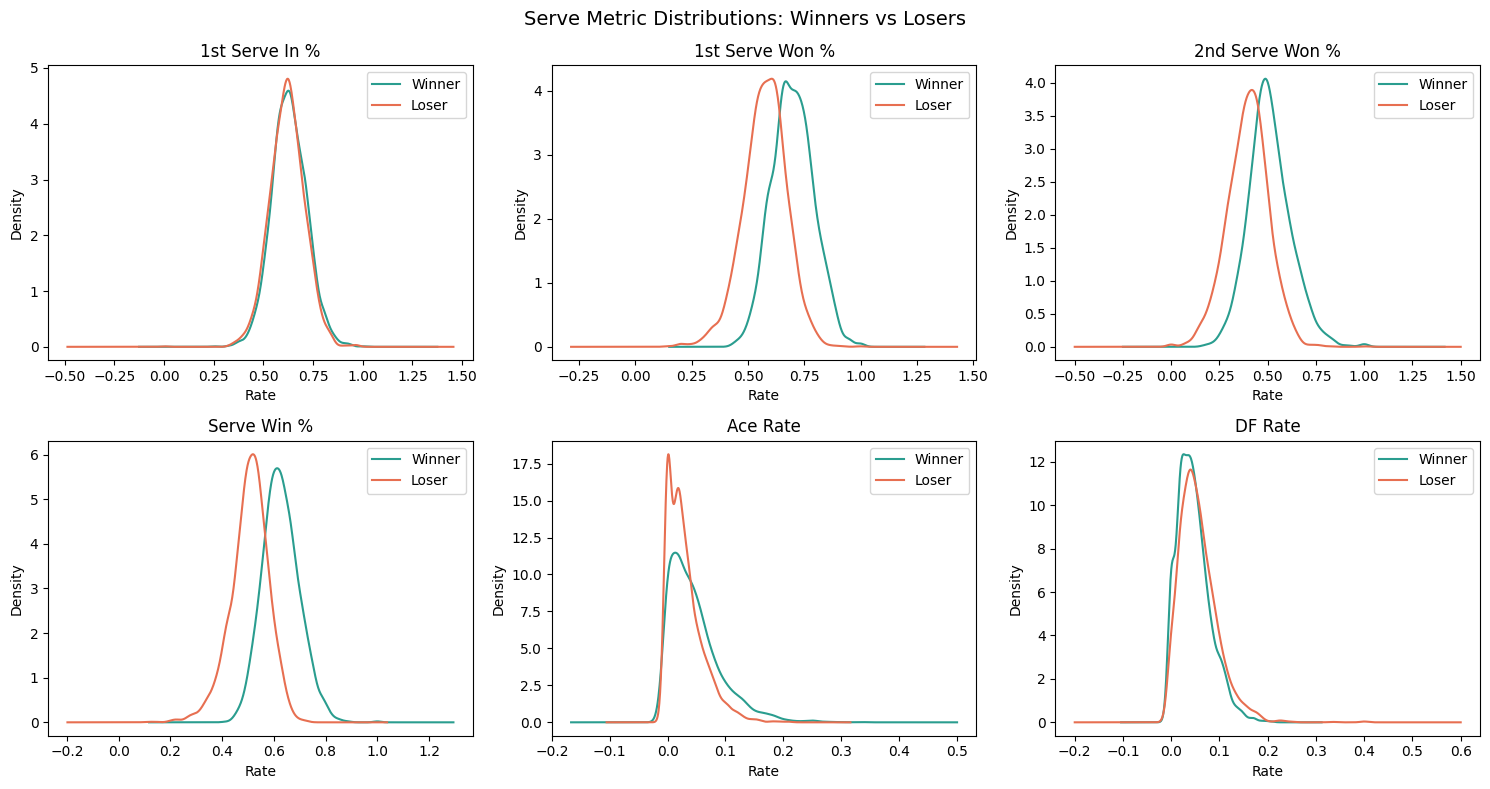

In [4]:
serve.plot_distributions()

## 3. Paired Match Comparison

Per-match winner-minus-loser differences and the rate at which winners outperformed losers.

In [5]:
paired = PairedMatchAnalyzer(FILE, cols=SERVE_COLS)
print(paired.summary())

                    mean_diff  winner_advantage_rate
1stIn_pct_diff         0.0112                 0.5358
1stWon_pct_diff        0.1239                 0.8506
2ndWon_pct_diff        0.1128                 0.7537
serve_won_pct_diff     0.1220                 0.9413
ace_rate_diff          0.0172                 0.5865


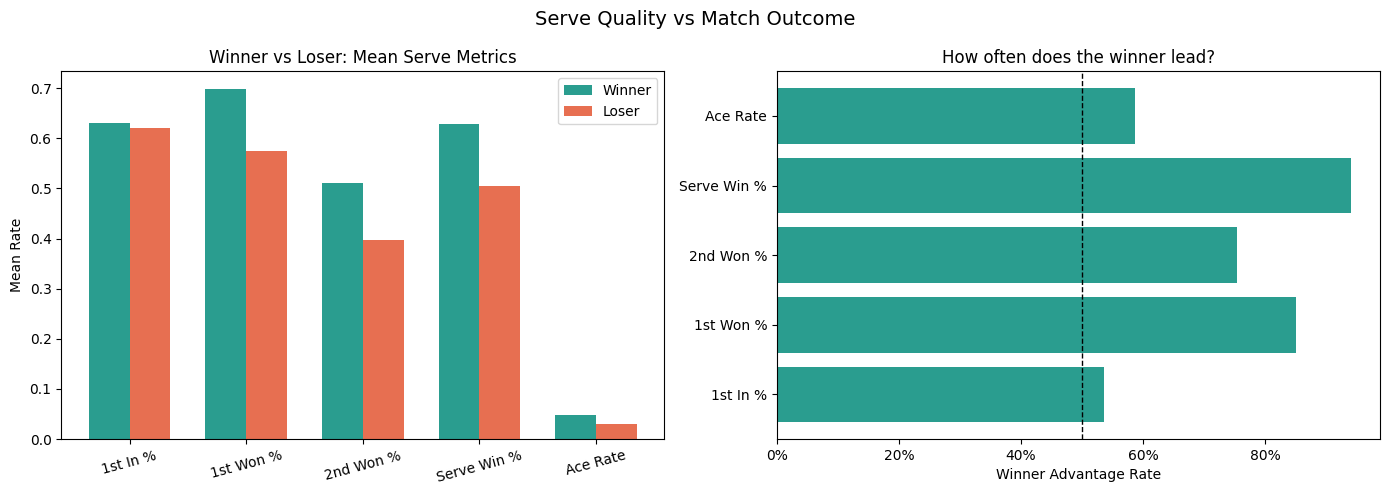

In [6]:
paired.plot_advantage()

## 4. Interactive Match Filter

Run the cell below to see available filter options, then use the next cell to query matches.

In [7]:
print("Surface:      ", dataset.options("surface"))
print("Round:        ", dataset.options("round"))
print("Tourney level:", dataset.options("tourney_level"))
print("Players (first 20):", sorted(df["winner_name"].dropna().unique().tolist())[:20])

Surface:       ['Clay', 'Grass', 'Hard']
Round:         ['BR', 'F', 'QF', 'R128', 'R16', 'R32', 'R64', 'RR', 'SF']
Tourney level: ['D', 'F', 'G', 'I', 'O', 'P', 'PM', 'W']
Players (first 20): ['Ajla Tomljanovic', 'Aleksandra Krunic', 'Alexandra Eala', 'Aliaksandra Sasnovich', 'Alina Korneeva', 'Alize Cornet', 'Alycia Parks', 'Amanda Anisimova', 'Ana Bogdan', 'Anastasia Pavlyuchenkova', 'Anastasia Potapova', 'Anastasia Zakharova', 'Anastasija Sevastova', 'Anca Alexia Todoni', 'Angela Fita Boluda', 'Angelique Kerber', 'Anhelina Kalinina', 'Ann Li', 'Anna Blinkova', 'Anna Bondar']


In [8]:
filters = prompt_filters(dataset)
filtered = filter_matches(df, **filters)
print(f"Found {len(filtered)} matches")
print(format_match_rows(filtered))

Available filters — press Enter at any step to skip (shows all).

Player (winner or loser) (press Enter to skip, or type a keyword to search):

Surface:
0. Skip
1. Clay
2. Grass
3. Hard

Round:
0. Skip
1. BR
2. F
3. QF
4. R128
5. R16
6. R32
7. R64
8. RR
9. SF

Tournament level:
0. Skip
1. D
2. F
3. G
4. I
5. O
6. P
7. PM
8. W

Winner (press Enter to skip, or type a keyword to search):

Loser (press Enter to skip, or type a keyword to search):

Found 10 matches
1. Iga Swiatek def. Angelique Kerber | Hard | F | United Cup | score: 6-3 6-0
2. Iga Swiatek def. Caroline Garcia | Hard | SF | United Cup | score: 4-6 6-1 6-1
3. Angelique Kerber def. Ajla Tomljanovic | Hard | SF | United Cup | score: 4-6 6-2 7-6(7)
4. Iga Swiatek def. Qinwen Zheng | Hard | QF | United Cup | score: 6-2 6-3
5. Caroline Garcia def. Malene Helgo | Hard | QF | United Cup | score: 6-2 6-7(6) 7-6(5)
6. Ajla Tomljanovic def. Natalija Stevanovic | Hard | QF | United Cup | score: 6-1 6-1
7. Maria Sakkari def. Angelique K